In [ ]:
!pip install gensim

# For loading pre-trained word embeddings
from gensim.models import KeyedVectors

# For numerical operations
import numpy as np

# For visualization
import matplotlib.pyplot as plt

# For dimensionality reduction
from sklearn.manifold import TSNE

In [ ]:
# Download the Google News Word2Vec model
# This file is ~3.6 GB, so it will take some time to download.
# !wget -c "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"
# !gunzip GoogleNews-vectors-negative300.bin.gz

# Or, for a smaller model for demonstration purposes, consider FastText or GloVe embeddings.
# For example, using a smaller pre-trained FastText model:
import gensim.downloader as api
model = api.load("fasttext-wiki-news-subwords-300")
print("Vocabulary Size:", len(model.key_to_index))
print("Vector for 'king':")
print(model['king'])

[==================================================] 100.0% 958.5/958.4MB downloaded


In [ ]:
words = [
    # Animals
    "dog", "cat", "lion", "tiger", "elephant", "wolf", "horse",

    # Fruits
    "apple", "banana", "mango", "orange", "grape", "pineapple",

    # Countries
    "india", "china", "usa", "france", "germany", "japan",

    # Cities
    "delhi", "mumbai", "paris", "berlin", "tokyo", "beijing",

    # Technology
    "computer", "laptop", "keyboard", "mouse", "internet",
    "software", "hardware",

    # Royalty
    "king", "queen", "prince", "princess", "man", "woman",

    # Vehicles
    "car", "bus", "train", "bike", "airplane"
]


In [ ]:
vectors = []

for word in words:
    if word in model:
        vectors.append(model[word])

vectors = np.array(vectors)


In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced_vectors = tsne.fit_transform(vectors)


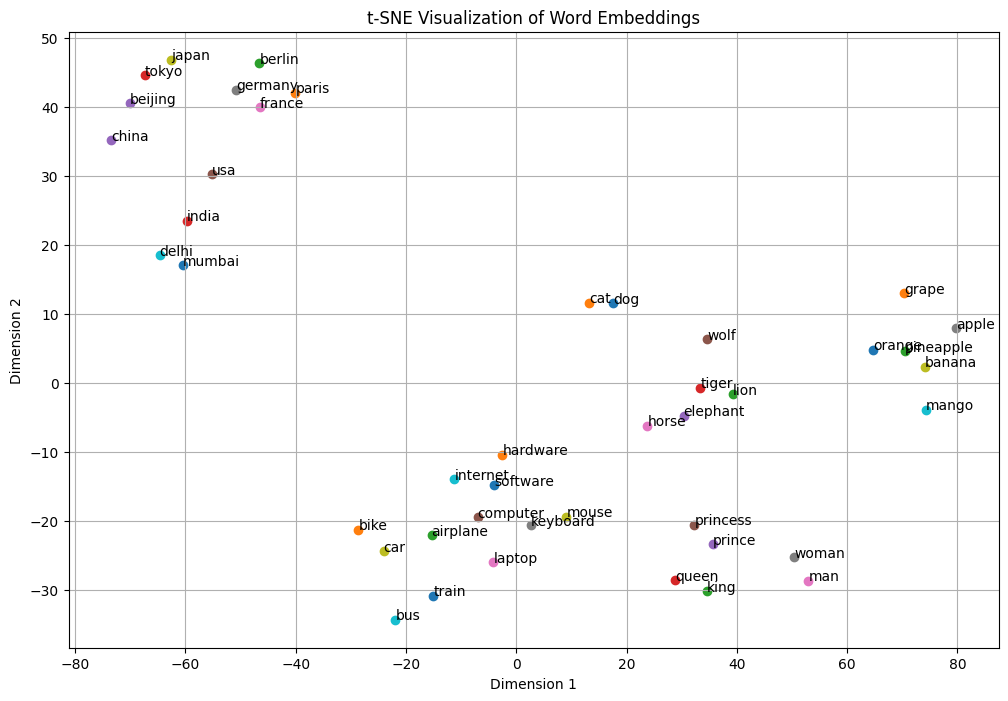

In [ ]:
plt.figure(figsize=(12, 8))

for i, word in enumerate(words):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1])
    plt.annotate(word,
                 (reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.title("t-SNE Visualization of Word Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()


The t-SNE visualization shows clear clustering of semantically similar words. Animal names such as dog, cat, lion, and tiger appear close to each other, forming a distinct group. Similarly, fruit names like apple, banana, and mango are clustered together. Countries and cities also form related clusters, with capital cities positioned near their respective countries. Technology-related words such as computer, laptop, and software appear close, indicating contextual similarity. Royal family terms like king, queen, prince, and princess are grouped together. Vehicles such as car, bus, and train form another cluster. Some words may appear slightly separated due to contextual usage differences in training data. Overall, the visualization demonstrates that word embeddings capture semantic relationships effectively.
